In [2]:
from typing import Annotated

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [3]:
load_dotenv()

True

In [4]:
llm = ChatGoogleGenerativeAI(model="gemini-3.8-flash")

In [5]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [9]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].text,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(text="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [10]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

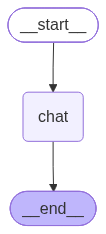

In [11]:
app

In [18]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [19]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='b5817014-896b-43d8-b5ff-133d2c74b974'),
  AIMessage(content=[{'type': 'text', 'text': 'Imagine you are blindfolded on a foggy mountain, and your goal is to walk down to the very bottom of the valley. \n\nBecause of the fog, you can’t see where the bottom is. **What do you do?**\n\n1. You feel the ground with your feet to find which way slopes **downward**.\n2. You take a step in that downward direction.\n3. You repeat this: feel the slope, take a step, feel the slope, take a step.\n4. Eventually, the ground feels completely flat under your feet. You know you’ve reached the bottom.\n\n**That is Gradient Descent.**\n\n### How computers use it:\n* **The Mountain:** Represents the computer’s **mistakes** (the higher up it is, the more wrong it is).\n* **The Bottom of the Valley:** Represents **perfection** (the lowest possible amount of mistakes).\n* **The "G

In [20]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [21]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [23]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

GoogleAPIError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [17]:
print(final_result["messages"][-1].text)

Imagine you are blindfolded on a foggy mountain, and your goal is to walk down to the very bottom of the valley. 

Because of the fog, you can’t see where the bottom is. **What do you do?**

1. You feel the ground with your feet to find which way slopes **downward**.
2. You take a step in that downward direction.
3. You repeat this: feel the slope, take a step, feel the slope, take a step.
4. Eventually, the ground feels completely flat under your feet. You know you’ve reached the bottom.

**That is Gradient Descent.**

### How computers use it:
* **The Mountain:** Represents the computer’s **mistakes** (the higher up it is, the more wrong it is).
* **The Bottom of the Valley:** Represents **perfection** (the lowest possible amount of mistakes).
* **The "Gradient":** A fancy math word for the **slope** of the ground. It tells the computer which direction makes the mistakes go down fastest.
* **The "Descent":** Taking steps downward.

### The one big catch: Step Size
In this process, th